# 07 - External Validation on Dataset 2 Overlapping Classes

This notebook evaluates the trained models on an **independent external dataset**.

## Important note
The image file name format does **not** need to match between Dataset 1 and Dataset 2.

Examples:
- Dataset 1: `阿胶_1.jpg`
- Dataset 2: `1.jpg`

This is fine because the label is taken from the **folder name**, not the image file name.

## Purpose
Dataset 1 may contain many pre-generated augmented images.  
To check whether the very high internal test accuracy is overly optimistic, this notebook uses **Dataset 2** as an **external validation set**.

## Models evaluated
- Improved CNN
- Transfer ResNet18

## Expected Dataset 2 structure
Place Dataset 2 here:

`I:\DeepLearning\ChineseHerb_Identify\data\raw\herb101_dataset_2\original\`

Example:

```text
herb101_dataset_2/
└── original/
    ├── 八角/
    │   ├── 1.jpg
    │   ├── 2.jpg
    │   └── ...
    ├── 巴戟天/
    ├── 白扁豆/
    └── ...
```


In [1]:
# Imports
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.7.1+cu128
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060


In [2]:
# Optional: display Chinese class names correctly on Windows
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
# Paths
PROJECT_ROOT = Path(r"I:\DeepLearning\ChineseHerb_Identify")

DATASET1_ROOT = PROJECT_ROOT / "data" / "raw" / "herb50_dataset_1" / "split_dataset"
DATASET1_TRAIN_DIR = DATASET1_ROOT / "train"

DATASET2_ROOT = PROJECT_ROOT / "data" / "raw" / "herb101_dataset_2" / "original"

IMPROVED_CNN_MODEL_PATH = PROJECT_ROOT / "models" / "cnn" / "improved_cnn_pytorch_best_model.pth"
TRANSFER_RESNET18_MODEL_PATH = PROJECT_ROOT / "models" / "transfer_learning" / "transfer_resnet18_pytorch_best_model.pth"

REPORTS_DIR = PROJECT_ROOT / "results" / "reports"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

for p in [REPORTS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DATASET1_TRAIN_DIR =", DATASET1_TRAIN_DIR)
print("DATASET2_ROOT      =", DATASET2_ROOT)
print("IMPROVED_CNN_MODEL =", IMPROVED_CNN_MODEL_PATH)
print("RESNET18_MODEL     =", TRANSFER_RESNET18_MODEL_PATH)

DATASET1_TRAIN_DIR = I:\DeepLearning\ChineseHerb_Identify\data\raw\herb50_dataset_1\split_dataset\train
DATASET2_ROOT      = I:\DeepLearning\ChineseHerb_Identify\data\raw\herb101_dataset_2\original
IMPROVED_CNN_MODEL = I:\DeepLearning\ChineseHerb_Identify\models\cnn\improved_cnn_pytorch_best_model.pth
RESNET18_MODEL     = I:\DeepLearning\ChineseHerb_Identify\models\transfer_learning\transfer_resnet18_pytorch_best_model.pth


In [5]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
# Image settings
IMPROVED_CNN_IMG_SIZE = 160
TRANSFER_RESNET18_IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0

In [7]:
# Helper functions
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_class_names(folder_path):
    if not folder_path.exists():
        return []
    return sorted([p.name for p in folder_path.iterdir() if p.is_dir()])

def list_image_files(folder_path):
    files = []
    for p in folder_path.rglob("*"):
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS:
            files.append(p)
    return sorted(files)

In [8]:
# Find overlapping classes
dataset1_classes = set(get_class_names(DATASET1_TRAIN_DIR))
dataset2_classes = set(get_class_names(DATASET2_ROOT))

overlap_classes = sorted(dataset1_classes.intersection(dataset2_classes))

print("Dataset 1 classes:", len(dataset1_classes))
print("Dataset 2 classes:", len(dataset2_classes))
print("Overlap classes  :", len(overlap_classes))
print("\nOverlap classes:")
print(overlap_classes)

overlap_summary_df = pd.DataFrame({"overlap_class_name": overlap_classes})
dataset_overlap_summary_path = REPORTS_DIR / "external_validation_overlap_classes.csv"
overlap_summary_df.to_csv(dataset_overlap_summary_path, index=False, encoding="utf-8-sig")
print("\nSaved overlap list to:", dataset_overlap_summary_path)

Dataset 1 classes: 50
Dataset 2 classes: 101
Overlap classes  : 15

Overlap classes:
['夏枯草', '巴戟天', '枸杞', '桃仁', '白头翁', '白扁豆', '白术', '白芍', '白茅根', '百合', '紫苑', '草果', '薏苡仁', '蝉蜕', '陈皮']

Saved overlap list to: I:\DeepLearning\ChineseHerb_Identify\results\reports\external_validation_overlap_classes.csv


In [9]:
# Check image counts in each overlap class
for class_name in overlap_classes:
    class_dir = DATASET2_ROOT / class_name
    image_files = list_image_files(class_dir)
    print(f"{class_name} -> {len(image_files)} images")

夏枯草 -> 86 images
巴戟天 -> 91 images
枸杞 -> 92 images
桃仁 -> 168 images
白头翁 -> 104 images
白扁豆 -> 124 images
白术 -> 124 images
白芍 -> 122 images
白茅根 -> 157 images
百合 -> 99 images
紫苑 -> 66 images
草果 -> 109 images
薏苡仁 -> 86 images
蝉蜕 -> 95 images
陈皮 -> 131 images


In [10]:
# Build external sample table
# Labels come from folder names, not file names.

dataset1_class_to_id = {class_name: idx for idx, class_name in enumerate(sorted(dataset1_classes))}

external_records = []
for class_name in overlap_classes:
    class_dir = DATASET2_ROOT / class_name

    if not class_dir.exists():
        print(f"Missing folder in Dataset 2: {class_dir}")
        continue

    image_files = list_image_files(class_dir)

    for img_path in image_files:
        external_records.append({
            "class_name": class_name,
            "dataset1_class_id": dataset1_class_to_id[class_name],
            "file_path": str(img_path),
            "file_name": img_path.name
        })

external_df = pd.DataFrame(external_records)
print("External overlap image count:", len(external_df))

if len(external_df) == 0:
    raise ValueError("No external overlap images were found. Please check Dataset 2 path or class folder names.")

display(external_df.head())

external_class_count_df = (
    external_df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
)

external_class_count_path = REPORTS_DIR / "external_validation_class_distribution.csv"
external_class_count_df.to_csv(external_class_count_path, index=False, encoding="utf-8-sig")
print("Saved class distribution to:", external_class_count_path)
display(external_class_count_df.head(20))

External overlap image count: 1654


,class_name,dataset1_class_id,file_path,file_name
0,夏枯草,6,I:\DeepLearning\ChineseHerb_Identify\data\raw\...,1.jpg
1,夏枯草,6,I:\DeepLearning\ChineseHerb_Identify\data\raw\...,10.jpg
2,夏枯草,6,I:\DeepLearning\ChineseHerb_Identify\data\raw\...,11.jpg
3,夏枯草,6,I:\DeepLearning\ChineseHerb_Identify\data\raw\...,12.jpg
4,夏枯草,6,I:\DeepLearning\ChineseHerb_Identify\data\raw\...,13.jpg


Saved class distribution to: I:\DeepLearning\ChineseHerb_Identify\results\reports\external_validation_class_distribution.csv


,class_name,count
0,桃仁,168
1,白茅根,157
2,陈皮,131
3,白扁豆,124
4,白术,124
5,白芍,122
6,草果,109
7,白头翁,104
8,百合,99
9,蝉蜕,95


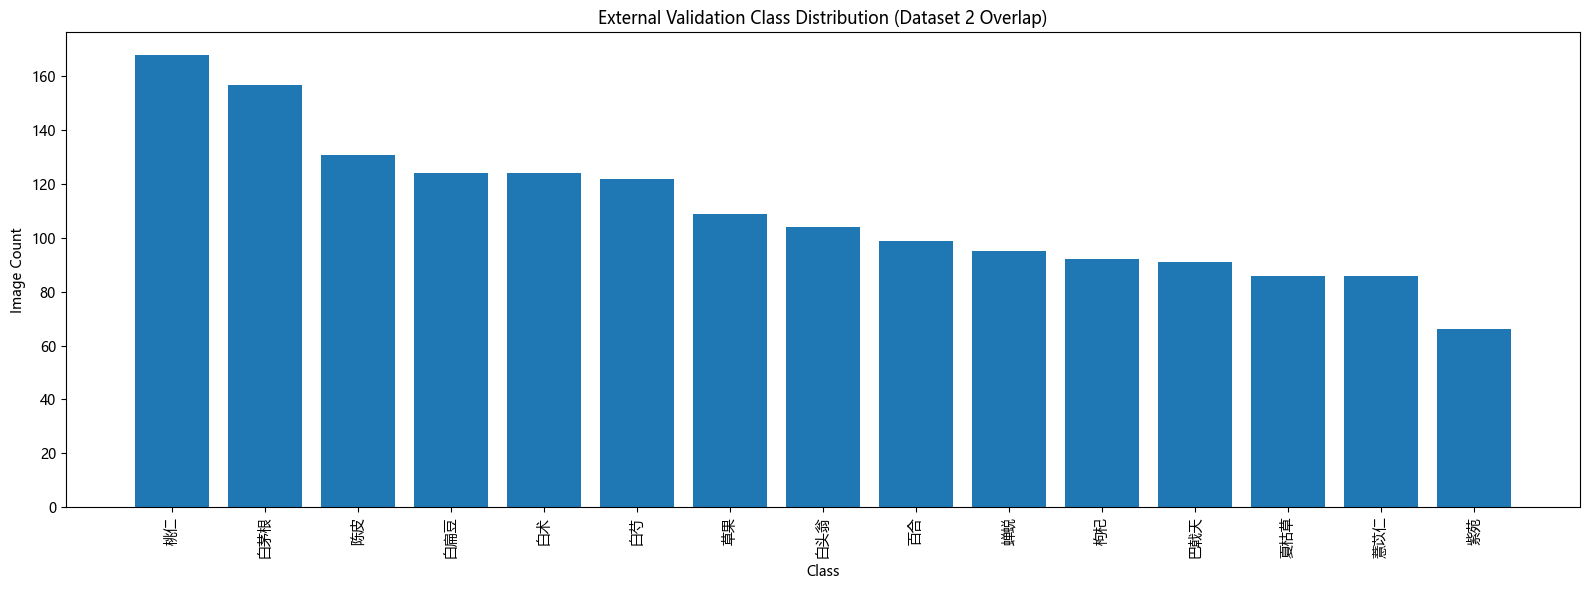

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\external_validation_overlap_class_distribution.png


In [11]:
# Plot overlap class distribution
plt.figure(figsize=(16, 6))
plt.bar(external_class_count_df["class_name"], external_class_count_df["count"])
plt.xticks(rotation=90)
plt.title("External Validation Class Distribution (Dataset 2 Overlap)")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.tight_layout()

external_distribution_figure_path = FIGURES_DIR / "external_validation_overlap_class_distribution.png"
plt.savefig(external_distribution_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", external_distribution_figure_path)

In [12]:
# Custom dataset for overlap-only external evaluation
class ExternalOverlapDataset(Dataset):
    def __init__(self, records_df, transform=None):
        self.records_df = records_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.records_df)

    def __getitem__(self, idx):
        row = self.records_df.iloc[idx]
        img = Image.open(row["file_path"]).convert("RGB")
        label = int(row["dataset1_class_id"])
        if self.transform is not None:
            img = self.transform(img)
        return img, label

In [13]:
# Transforms for external evaluation
improved_cnn_eval_transform = transforms.Compose([
    transforms.Resize((IMPROVED_CNN_IMG_SIZE, IMPROVED_CNN_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

transfer_resnet18_eval_transform = transforms.Compose([
    transforms.Resize((TRANSFER_RESNET18_IMG_SIZE, TRANSFER_RESNET18_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [14]:
# Build dataloaders
improved_cnn_external_dataset = ExternalOverlapDataset(external_df, transform=improved_cnn_eval_transform)
transfer_resnet18_external_dataset = ExternalOverlapDataset(external_df, transform=transfer_resnet18_eval_transform)

improved_cnn_external_loader = DataLoader(
    improved_cnn_external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

transfer_resnet18_external_loader = DataLoader(
    transfer_resnet18_external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Improved CNN external batches:", len(improved_cnn_external_loader))
print("ResNet18 external batches    :", len(transfer_resnet18_external_loader))

Improved CNN external batches: 26
ResNet18 external batches    : 26


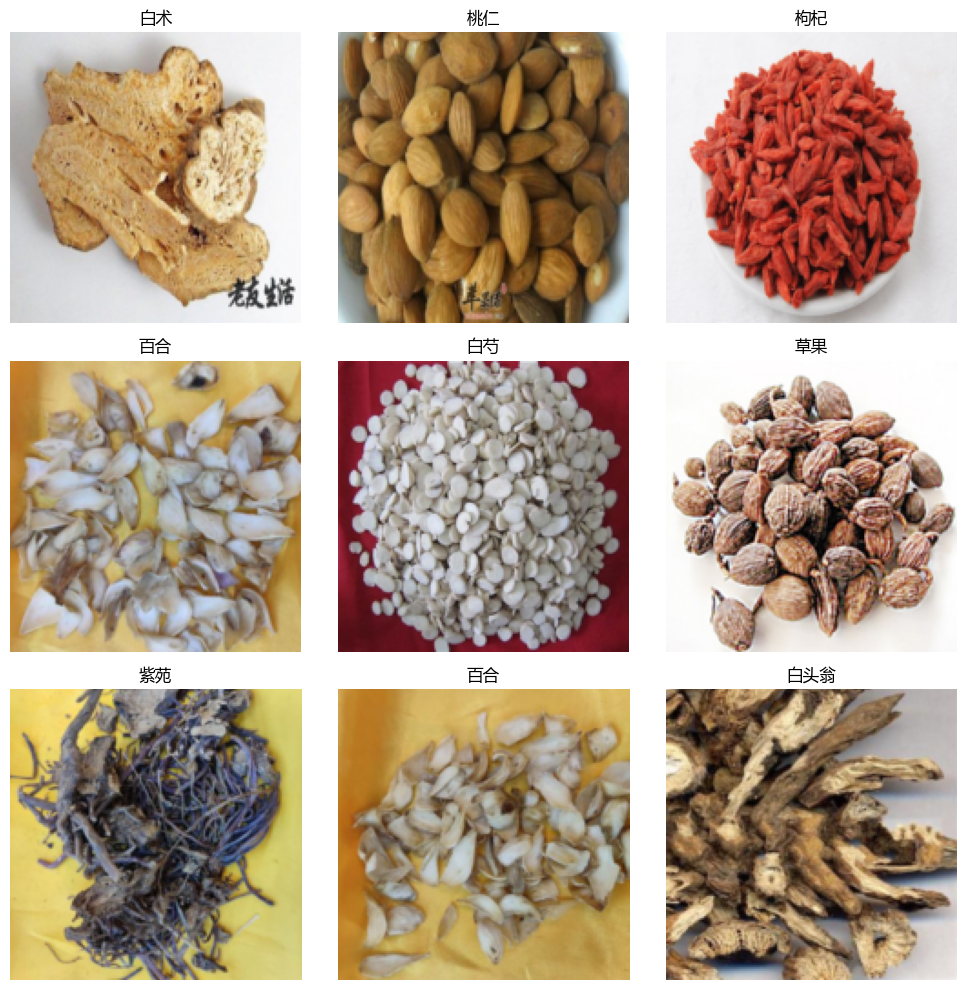

In [15]:
# Preview a few external images
preview_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

preview_dataset = ExternalOverlapDataset(external_df, transform=preview_transform)
preview_loader = DataLoader(preview_dataset, batch_size=9, shuffle=True, num_workers=0)

images, labels = next(iter(preview_loader))
class_names_sorted = sorted(dataset1_classes)

plt.figure(figsize=(10, 10))
for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(class_names_sorted[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Model definitions
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        return self.block(x)

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, dropout_rate=0.10),
            ConvBlock(32, 64, dropout_rate=0.15),
            ConvBlock(64, 128, dropout_rate=0.20),
            ConvBlock(128, 256, dropout_rate=0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

def build_transfer_resnet18(num_classes):
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

In [17]:
# Load trained models
num_classes = len(dataset1_classes)

improved_cnn_model = ImprovedCNN(num_classes=num_classes).to(device)
improved_cnn_model.load_state_dict(torch.load(IMPROVED_CNN_MODEL_PATH, map_location=device))
improved_cnn_model.eval()

transfer_resnet18_model = build_transfer_resnet18(num_classes=num_classes).to(device)
transfer_resnet18_model.load_state_dict(torch.load(TRANSFER_RESNET18_MODEL_PATH, map_location=device))
transfer_resnet18_model.eval()

print("Loaded Improved CNN from:", IMPROVED_CNN_MODEL_PATH)
print("Loaded Transfer ResNet18 from:", TRANSFER_RESNET18_MODEL_PATH)

Loaded Improved CNN from: I:\DeepLearning\ChineseHerb_Identify\models\cnn\improved_cnn_pytorch_best_model.pth
Loaded Transfer ResNet18 from: I:\DeepLearning\ChineseHerb_Identify\models\transfer_learning\transfer_resnet18_pytorch_best_model.pth


In [18]:
# Evaluation function
def evaluate_external(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    accuracy = (all_labels == all_preds).mean()

    return accuracy, all_labels, all_preds

In [19]:
# Restrict reports to overlap classes only
overlap_class_to_id = {cls: dataset1_class_to_id[cls] for cls in overlap_classes}
overlap_label_ids = [overlap_class_to_id[cls] for cls in overlap_classes]
overlap_display_names = overlap_classes

print("Overlap class count:", len(overlap_display_names))
print("Overlap label IDs:", overlap_label_ids)

Overlap class count: 15
Overlap label IDs: [6, 9, 14, 17, 21, 22, 23, 25, 26, 28, 35, 39, 41, 43, 48]


In [20]:
# Evaluate Improved CNN on external dataset
improved_cnn_external_accuracy, improved_cnn_external_y_true, improved_cnn_external_y_pred = evaluate_external(
    improved_cnn_model,
    improved_cnn_external_loader,
    device
)

print(f"Improved CNN External Accuracy: {improved_cnn_external_accuracy:.4f}")

  0%|          | 0/26 [00:00<?, ?it/s]

Improved CNN External Accuracy: 0.6034


In [21]:
# Improved CNN classification report (overlap classes only)
improved_cnn_external_report_dict = classification_report(
    improved_cnn_external_y_true,
    improved_cnn_external_y_pred,
    labels=overlap_label_ids,
    target_names=overlap_display_names,
    output_dict=True,
    zero_division=0
)

improved_cnn_external_report_df = pd.DataFrame(improved_cnn_external_report_dict).transpose()
improved_cnn_external_report_path = REPORTS_DIR / "external_validation_improved_cnn_classification_report.csv"
improved_cnn_external_report_df.to_csv(improved_cnn_external_report_path, encoding="utf-8-sig")

print("Saved:", improved_cnn_external_report_path)
display(improved_cnn_external_report_df.head(20))

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\external_validation_improved_cnn_classification_report.csv


,precision,recall,f1-score,support
夏枯草,0.892857,0.290698,0.438596,86.0
巴戟天,0.954545,0.461538,0.622222,91.0
枸杞,0.977273,0.934783,0.955556,92.0
桃仁,0.988372,0.505952,0.669291,168.0
白头翁,0.821429,0.442308,0.575000,104.0
白扁豆,0.712500,0.919355,0.802817,124.0
白术,0.916667,0.177419,0.297297,124.0
白芍,0.947368,0.885246,0.915254,122.0
白茅根,1.000000,0.535032,0.697095,157.0
百合,0.983051,0.585859,0.734177,99.0


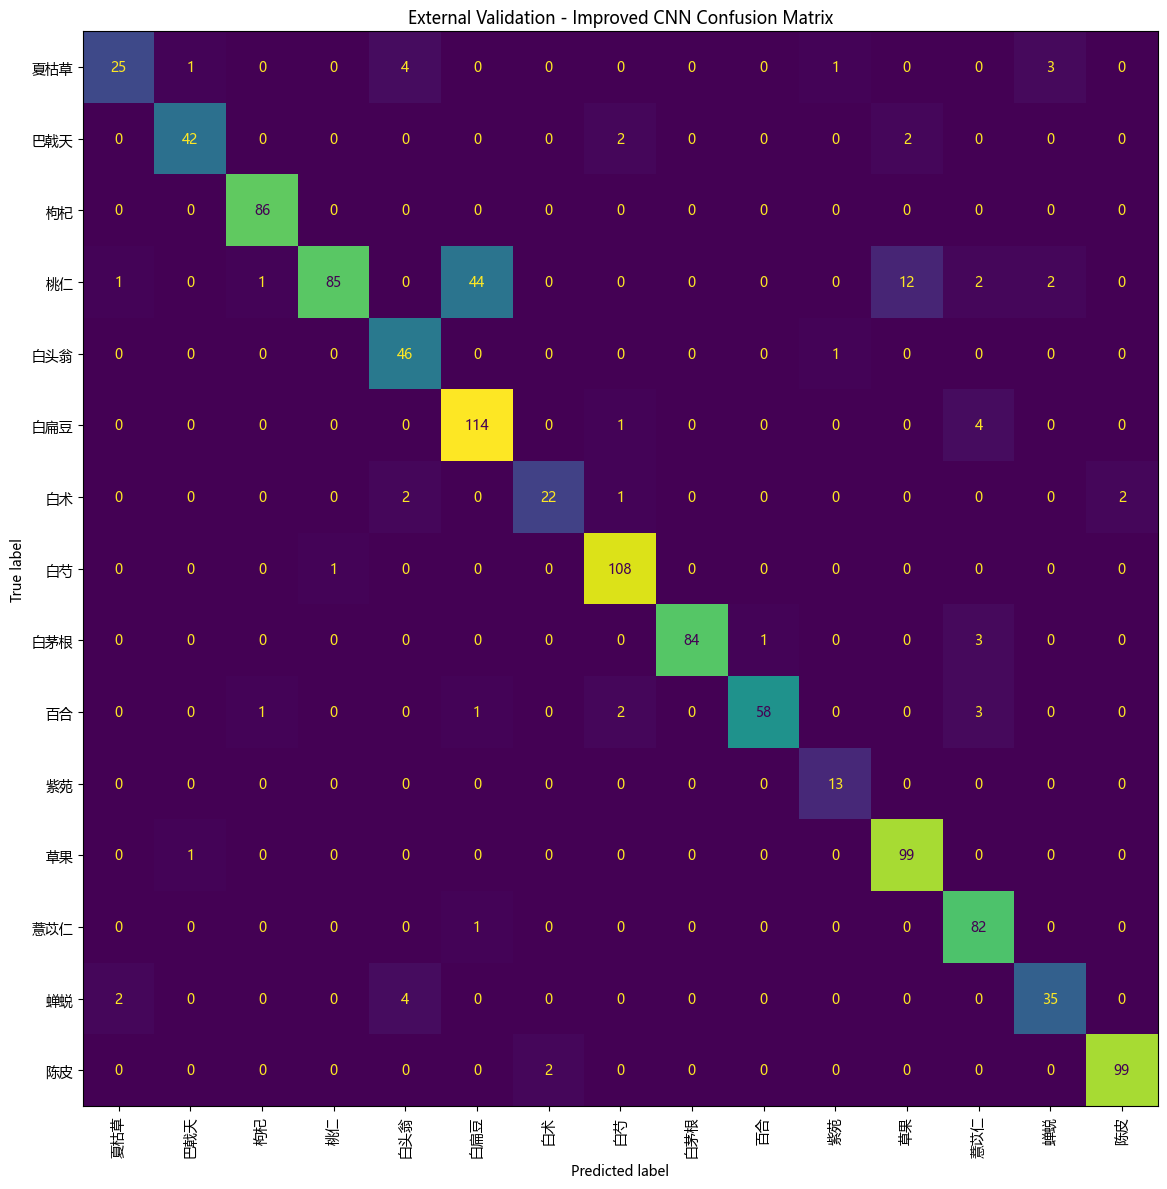

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\external_validation_improved_cnn_confusion_matrix.png


In [22]:
# Improved CNN confusion matrix (overlap classes only)
improved_cnn_external_cm = confusion_matrix(
    improved_cnn_external_y_true,
    improved_cnn_external_y_pred,
    labels=overlap_label_ids
)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cnn_external_cm,
    display_labels=overlap_display_names
)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("External Validation - Improved CNN Confusion Matrix")
plt.tight_layout()

improved_cnn_external_cm_path = FIGURES_DIR / "external_validation_improved_cnn_confusion_matrix.png"
plt.savefig(improved_cnn_external_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", improved_cnn_external_cm_path)

In [23]:
# Evaluate Transfer ResNet18 on external dataset
transfer_resnet18_external_accuracy, transfer_resnet18_external_y_true, transfer_resnet18_external_y_pred = evaluate_external(
    transfer_resnet18_model,
    transfer_resnet18_external_loader,
    device
)

print(f"Transfer ResNet18 External Accuracy: {transfer_resnet18_external_accuracy:.4f}")

  0%|          | 0/26 [00:00<?, ?it/s]

Transfer ResNet18 External Accuracy: 0.7854


In [24]:
# Transfer ResNet18 classification report (overlap classes only)
transfer_resnet18_external_report_dict = classification_report(
    transfer_resnet18_external_y_true,
    transfer_resnet18_external_y_pred,
    labels=overlap_label_ids,
    target_names=overlap_display_names,
    output_dict=True,
    zero_division=0
)

transfer_resnet18_external_report_df = pd.DataFrame(transfer_resnet18_external_report_dict).transpose()
transfer_resnet18_external_report_path = REPORTS_DIR / "external_validation_transfer_resnet18_classification_report.csv"
transfer_resnet18_external_report_df.to_csv(transfer_resnet18_external_report_path, encoding="utf-8-sig")

print("Saved:", transfer_resnet18_external_report_path)
display(transfer_resnet18_external_report_df.head(20))

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\external_validation_transfer_resnet18_classification_report.csv


,precision,recall,f1-score,support
夏枯草,1.000000,0.662791,0.797203,86.0
巴戟天,0.950617,0.846154,0.895349,91.0
枸杞,0.978495,0.989130,0.983784,92.0
桃仁,0.985816,0.827381,0.899676,168.0
白头翁,0.767442,0.317308,0.448980,104.0
白扁豆,0.991379,0.927419,0.958333,124.0
白术,0.884615,0.370968,0.522727,124.0
白芍,0.949153,0.918033,0.933333,122.0
白茅根,1.000000,0.955414,0.977199,157.0
百合,1.000000,0.767677,0.868571,99.0


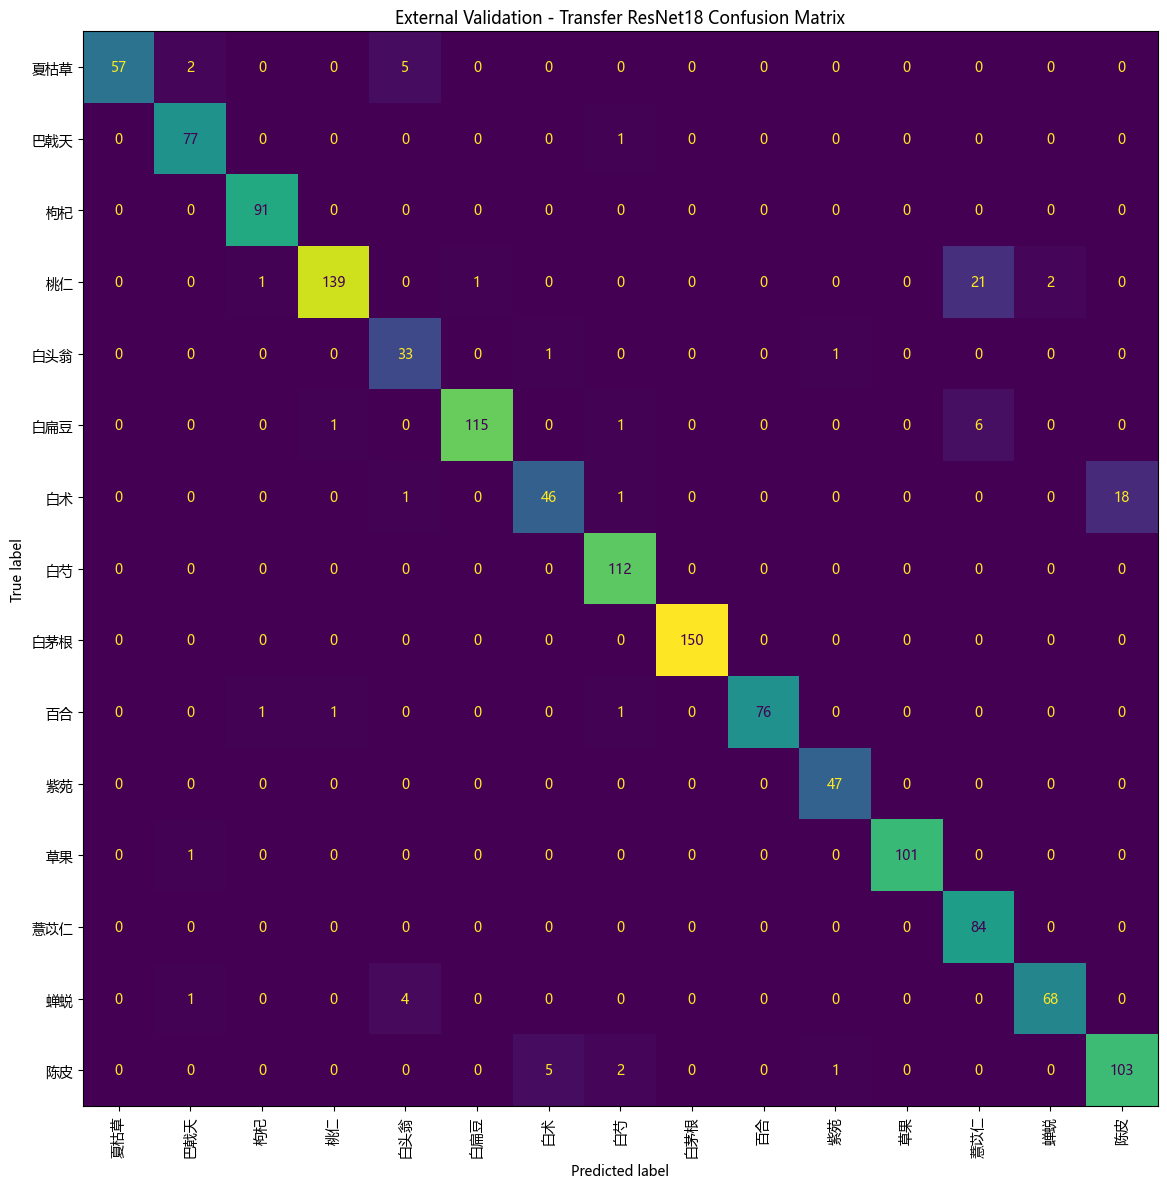

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\external_validation_transfer_resnet18_confusion_matrix.png


In [25]:
# Transfer ResNet18 confusion matrix (overlap classes only)
transfer_resnet18_external_cm = confusion_matrix(
    transfer_resnet18_external_y_true,
    transfer_resnet18_external_y_pred,
    labels=overlap_label_ids
)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=transfer_resnet18_external_cm,
    display_labels=overlap_display_names
)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("External Validation - Transfer ResNet18 Confusion Matrix")
plt.tight_layout()

transfer_resnet18_external_cm_path = FIGURES_DIR / "external_validation_transfer_resnet18_confusion_matrix.png"
plt.savefig(transfer_resnet18_external_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", transfer_resnet18_external_cm_path)

In [26]:
# Final comparison table
external_validation_comparison_df = pd.DataFrame([
    {
        "model_name": "improved_cnn_pytorch",
        "external_accuracy": improved_cnn_external_accuracy,
        "num_external_images": len(external_df),
        "num_overlap_classes": len(overlap_classes)
    },
    {
        "model_name": "transfer_resnet18_pytorch",
        "external_accuracy": transfer_resnet18_external_accuracy,
        "num_external_images": len(external_df),
        "num_overlap_classes": len(overlap_classes)
    }
])

external_validation_comparison_path = REPORTS_DIR / "external_validation_model_comparison.csv"
external_validation_comparison_df.to_csv(external_validation_comparison_path, index=False, encoding="utf-8-sig")

print("Saved:", external_validation_comparison_path)
display(external_validation_comparison_df)

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\external_validation_model_comparison.csv


,model_name,external_accuracy,num_external_images,num_overlap_classes
0,improved_cnn_pytorch,0.603386,1654,15
1,transfer_resnet18_pytorch,0.785369,1654,15


In [27]:
# Save summary json
external_validation_summary = {
    "num_dataset1_classes": len(dataset1_classes),
    "num_dataset2_classes": len(dataset2_classes),
    "num_overlap_classes": len(overlap_classes),
    "num_external_images": len(external_df),
    "improved_cnn_external_accuracy": float(improved_cnn_external_accuracy),
    "transfer_resnet18_external_accuracy": float(transfer_resnet18_external_accuracy),
    "device": str(device)
}

external_validation_summary_path = REPORTS_DIR / "external_validation_summary.json"
with open(external_validation_summary_path, "w", encoding="utf-8") as f:
    json.dump(external_validation_summary, f, ensure_ascii=False, indent=4)

print("Saved:", external_validation_summary_path)
external_validation_summary

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\external_validation_summary.json


{'num_dataset1_classes': 50,
 'num_dataset2_classes': 101,
 'num_overlap_classes': 15,
 'num_external_images': 1654,
 'improved_cnn_external_accuracy': 0.6033857315598549,
 'transfer_resnet18_external_accuracy': 0.7853688029020556,
 'device': 'cuda'}